In [29]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [30]:
N = 3
cycles = 2
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [0.5]*N
no_occurrences_sds = [0.5]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0.5, 0.5, 0.5]
Number of occurrences standard deviations: [0.5, 0.5, 0.5]


In [31]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
        
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        sample = int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))
        return sample if sample >= 0 else 0


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        sample = np.random.normal(loc=1, scale=0)
        return .5 if sample <= .5 else sample

In [32]:
etg = ExampleETG(occurrences, time_intervals, noise_sds, no_occurrences_sds)
ess = ExampleSampleSpace()

In [33]:
def on_event(event):
    print(f"event: {event}")
    print("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(cycles*N)
print("Generated data:", data)

event: (0.28415856806223694, 1.0)
--------
event: (0.6134095493920118, 1.0)
--------
event: (1.1045748883745685, 1.0)
--------
event: (0.7673509441881385, 1.0)
--------
event: (2.860301638548737, 1.0)
--------
event: (3.151808813730999, 1.0)
--------
event: (3.465908939398545, 1.0)
--------
event: (3.1532545152621543, 1.0)
--------
event: (4.408809367018636, 1.0)
--------
event: (4.926297007705211, 1.0)
--------
event: (5.066893113147436, 1.0)
--------
event: (5.076937647516965, 1.0)
--------
event: (5.941907194551171, 1.0)
--------
Generated data: [(0.28415856806223694, 1.0), (0.6134095493920118, 1.0), (1.1045748883745685, 1.0), (0.7673509441881385, 1.0), (2.860301638548737, 1.0), (3.151808813730999, 1.0), (3.465908939398545, 1.0), (3.1532545152621543, 1.0), (4.408809367018636, 1.0), (4.926297007705211, 1.0), (5.066893113147436, 1.0), (5.076937647516965, 1.0), (5.941907194551171, 1.0)]


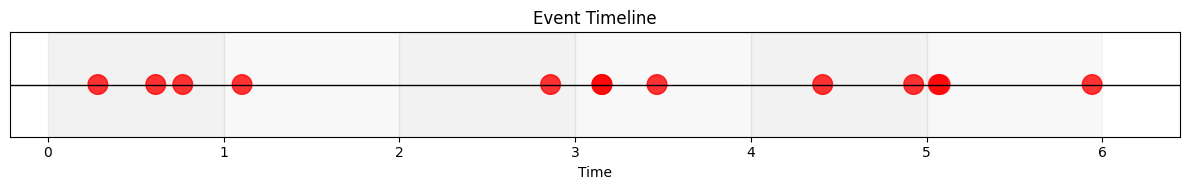

In [34]:
from Analytics import plot_timeline, extend_intervals
plot_timeline(data, extend_intervals(time_intervals, cycles))


In [35]:
from Analytics import count_number_of_occurrences_in_intervals
count_number_of_occurrences_in_intervals(extend_intervals(time_intervals, cycles), data)

[3, 1, 1, 3, 2, 3]